In [1]:
# 参数设置
import numpy as np
from matplotlib import pyplot as plt
from CSLP.data import x_coords, y_coords,demands
from CSLP.NearP import near1
from CSLP.APO import APO
from CSLP.BKA import BKA
from CSLP.BSLO import BSLO
from CSLP.GWO import GWO
from CSLP.HO import HO
from CSLP.IVY import IVY
from CSLP.PSO import PSO
from CSLP.RBMO import RBMO
from CSLP.WOA import WOA
from CSLP.GA import GA
from CSLP.MSGWO import MSGWO
from CSLP.target import objective_function
plt.rcParams['font.family'] = 'Times New Roman'
# n = 500
Max_cs = 2  # 充电站数量
H = 0.15 #每公里耗电量
f_j = 50  # 每个充电站的固定建设成本(万元)
z_j = 0.00001  # 每单位容量(KWh)的建设成本(万元)
C_max = 7*1e5 # 每个充电站的最大容量(kwh)
num_wolves=30
max_iter=50

# x_coords = np.random.uniform(0, 1, n)
# y_coords = np.random.uniform(0, 1, n)
# demands = np.random.uniform(0, 1, n)  # 需求量在 1 到 10 之间
# import pandas as pd
# 
# # 正确的方式读取Excel文件的第一个工作表
# excel_path = 'data1.xlsx'  # Excel文件的路径
# sheet_name = 1  # 第一个工作表的索引

# 使用read_excel读取指定工作表
# df = pd.read_excel(excel_path, sheet_name=sheet_name)
# 假设Excel文件中的列分别命名为 'X', 'Y', 'Demand'
# 将列数据转换为NumPy数组
# x_coords = df['x'].values
# y_coords = df['y'].values
# demands = df['C'].values
# print(len(x_coords))
# 现在你可以使用这些数组进行后续操作
# print(x_coords)
# print(y_coords)
# print(demands)
# 
# # 打印前几个需求点以确认
# for i in range(10):
#     print(f"需求点 {i + 1}: 坐标 ({x_coords[i]}, {y_coords[i]}), 需求量 {demands[i]}")

In [2]:
B = [[None for _ in range(0)] for _ in range(11)]
C = [[None for _ in range(0)] for _ in range(11)]
F = np.full(11, np.inf)
Num_CS = np.zeros(11)
for i in range(2,Max_cs+1):
    m = i
    bounds = np.array([[0+1e-2, 1-1e-2], [0+1e-2, 1-1e-2], [100, C_max]])  # 每个充电站的 x, y 坐标和容量的边界    # 实例化和优化
    woa = WOA(objective_function, bounds, x_coords, y_coords, demands, m, f_j, z_j, C_max, num_wolves, max_iter)
    pso = PSO(objective_function, bounds, x_coords, y_coords, demands, m, f_j, z_j, C_max, num_wolves, max_iter)
    gwo = GWO(objective_function, bounds, x_coords, y_coords, demands, m, f_j, z_j, C_max, num_wolves, max_iter)
    ho = HO(objective_function, bounds, x_coords, y_coords, demands, m, f_j, z_j, C_max, num_wolves, max_iter)
    bslo = BSLO(objective_function, bounds, x_coords, y_coords, demands, m, f_j, z_j, C_max, num_wolves, max_iter)
    rbmo = RBMO(objective_function, bounds, x_coords, y_coords, demands, m, f_j, z_j, C_max, num_wolves, max_iter)
    apo = APO(objective_function, bounds, x_coords, y_coords, demands, m, f_j, z_j, C_max, num_wolves, max_iter)
    ivy = IVY(objective_function, bounds, x_coords, y_coords, demands, m, f_j, z_j, C_max, num_wolves, max_iter)
    bka = BKA(objective_function, bounds, x_coords, y_coords, demands, m, f_j, z_j, C_max, num_wolves, max_iter)
    ga = GA(objective_function, bounds, x_coords, y_coords, demands, m, f_j, z_j, C_max, num_wolves, max_iter)
    msgwo = MSGWO(objective_function, bounds, x_coords, y_coords, demands, m, f_j, z_j, C_max, num_wolves, max_iter)

    # 优化
    best_position1, best_score1, convergence_curve1 = woa.optimize()
    if best_score1<F[0]:
        F[0] = best_score1
        Num_CS[0] = i
        B[0] = best_position1
        C[0] = convergence_curve1
    best_position2, best_score2, convergence_curve2 = pso.optimize()
    if best_score2<F[1]:
        F[1] = best_score2
        Num_CS[1] = i
        B[1] = best_position2
        C[1] = convergence_curve2
    best_position3, best_score3, convergence_curve3 = gwo.optimize()
    if best_score3<F[2]:
        F[2] = best_score3
        Num_CS[2] = i
        B[2] = best_position3
        C[2] = convergence_curve3
    best_position4, best_score4, convergence_curve4 = ho.optimize()
    if best_score4<F[3]:
        F[3] = best_score4
        Num_CS[3] = i
        B[3] = best_position4
        C[3] = convergence_curve4
    best_position5, best_score5, convergence_curve5 = bslo.optimize()
    if best_score5<F[4]:
        F[4] = best_score5
        Num_CS[4] = i
        B[4] = best_position5
        C[4] = convergence_curve5
    best_position6, best_score6, convergence_curve6 = rbmo.optimize()
    if best_score6<F[5]:
        F[5] = best_score6
        Num_CS[5] = i
        B[5] = best_position6
        C[5] = convergence_curve6
    best_position7, best_score7, convergence_curve7 = apo.optimize()
    if best_score7<F[6]:
        F[6] = best_score7
        Num_CS[6] = i
        B[6] = best_position7
        C[6] = convergence_curve7
    best_position8, best_score8, convergence_curve8 = ivy.optimize()
    if best_score8<F[7]:
        F[7] = best_score8
        Num_CS[7] = i
        B[7] = best_position8
        C[7] = convergence_curve8
    best_position9, best_score9, convergence_curve9 = bka.optimize()
    if best_score9<F[8]:
        F[8] = best_score9
        Num_CS[8] = i
        B[8] = best_position9
        C[8] = convergence_curve9
    best_position10, best_score10, convergence_curve10 = ga.optimize()
    if best_score10<F[9]:
        F[9] = best_score10
        Num_CS[9] = i
        B[9] = best_position10
        C[9] = convergence_curve10
    best_position, best_score, convergence_curve = msgwo.optimize()
    if best_score<F[10]:
        F[10] = best_score
        Num_CS[10] = i
        B[10] = best_position
        C[10] = convergence_curve
print(F)
print(Num_CS)
print(B[-1])

*************WOA****************
最优位置： [[0.73 0.3 ]
 [0.11 0.47]]
最优容量： [283645.54705517  48967.58855722]
最优目标函数值： 685.396150872076
*************PSO****************
最优位置： [[0.24 0.22]
 [0.73 0.3 ]]
最优容量： [27846.26569965 24505.67194816]
最优目标函数值： 684.2973758235944
*************GWO****************
最优位置： [[0.73 0.3 ]
 [0.28 0.05]]
最优容量： [75410.39707767 27374.72426727]
最优目标函数值： 708.2927236323455
*************HO****************
最优位置： [[0.73604781 0.48001617]
 [0.2274952  0.15857012]]
最优容量： [139661.66474897 545956.22446587]
最优目标函数值： 690.4129168988673
*************BSLO****************
最优位置： [[0.01 0.54]
 [0.74 0.94]]
最优容量： [260706.1368374  211881.06221352]
最优目标函数值： 688.4996844714356
*************RBMO****************
最优位置： [[0.77 0.58]
 [0.24 0.22]]
最优容量： [566681.09396045 396745.76341029]
最优目标函数值： 693.408212927011
*************APO****************
最优位置： [[0.24 0.22]
 [0.73 0.3 ]]
最优容量： [231126.50900979 287394.49740287]
最优目标函数值： 688.9590665112429
*************IVY****************
最优位置： [[0.73 0.3 

In [7]:
# A = []
# for i in range(len(B)):
#     a = near1(B[i],int(Num_CS[i]))
#     A.append(a)
# print(A)

[[17, 18], [9, 17], [17, 19], [3, 9], [5, 7], [3, 9], [9, 17], [17, 9], [17, 9], [17, 9], [9, 17]]


In [9]:
from CSLP.cost import cost

for i in range(len(B)):
    print(B[i])
    cost(B[i], x_coords, y_coords,int(Num_CS[i]), f_j, z_j)

[7.30000000e-01 3.00000000e-01 2.83645547e+05 1.10000000e-01
 4.70000000e-01 4.89675886e+04]
[7.30000000e-01 3.00000000e-01 2.83645547e+05 1.10000000e-01
 4.70000000e-01 4.89675886e+04]
1020.5098960176642
100
3.3261313561238914
2.0
734.7671251327182
[283645.54705517  48967.58855722]
[2.40000000e-01 2.20000000e-01 2.78462657e+04 7.30000000e-01
 3.00000000e-01 2.45056719e+04]
[2.40000000e-01 2.20000000e-01 2.78462657e+04 7.30000000e-01
 3.00000000e-01 2.45056719e+04]
808.0192450654391
100
0.5235193764781461
2.0
581.7738564471163
[27846.26569965 24505.67194816]
[7.30000000e-01 3.00000000e-01 7.54103971e+04 2.80000000e-01
 5.00000000e-02 2.73747243e+04]
[7.30000000e-01 3.00000000e-01 7.54103971e+04 2.80000000e-01
 5.00000000e-02 2.73747243e+04]
840.6456561373557
100
1.0278512134494235
2.0
605.2648724188962
[75410.39707767 27374.72426727]
[7.36047808e-01 4.80016174e-01 1.39661665e+05 2.27495198e-01
 1.58570121e-01 5.45956224e+05]
[7.36047808e-01 4.80016174e-01 1.39661665e+05 2.27495198e-01


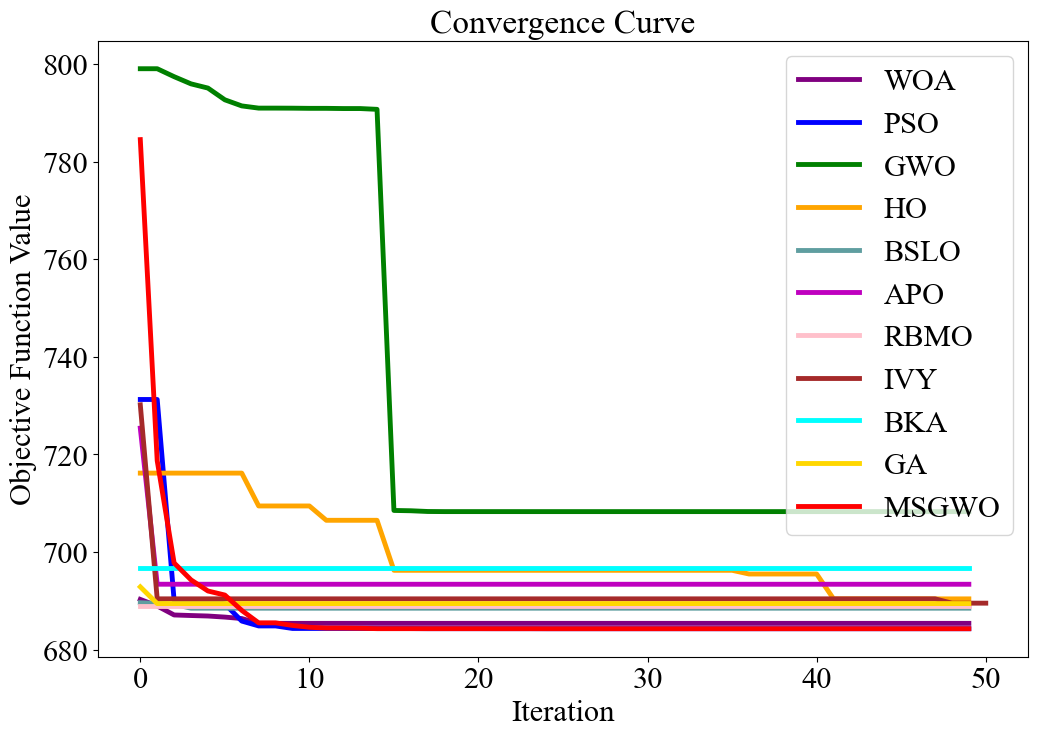

In [4]:

# stations_positions = best_position.reshape((m, 3))[:, :2]
# stations_capacities = best_position.reshape((m, 3))[:, 2]
# 绘制收敛曲线
def plot_lines_with_larger_fonts_and_thicker_lines(curves, labels, colors):
    plt.figure(figsize=(12, 8))

    for curve, label, color in zip(curves, labels, colors):
        plt.plot(curve, label=label, color=color, linewidth=3.5)  # 增加线条粗细
    plt.xlabel('Iteration', fontsize=22)
    plt.ylabel('Objective Function Value', fontsize=22)
    plt.title('Convergence Curve', fontsize=24)
    plt.legend(fontsize=22)
    # plt.grid(True)
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.show()

    # 使用示例数据运行函数
curves = C
labels = ['WOA','PSO','GWO', 'HO', 'BSLO','APO', 'RBMO', 'IVY',  'BKA','GA','MSGWO']
colors = ['purple','blue','green','orange','cadetblue', 'm', 'pink', 'brown', 'cyan','gold','red']
plot_lines_with_larger_fonts_and_thicker_lines(curves, labels, colors)

In [13]:
import pandas as pd

# 假设这是你的三个列表
list1 = ['a1', 'a2', 'a3']
list2 = [1, 2, 3]
list3 = [4.1, 5.2, 6.3]

# 创建一个空的DataFrame
df = pd.DataFrame()

# 将每个列表作为一行添加到DataFrame中
df = df.append(pd.DataFrame([list1]), ignore_index=True)
df = df.append(pd.DataFrame([list2]), ignore_index=True)
df = df.append(pd.DataFrame([list3]), ignore_index=True)

# 重命名列，如果需要的话
df.columns = ['Column1', 'Column2', 'Column3']

# 保存到Excel文件
df.to_excel('three_rows.xlsx', index=False)

AttributeError: 'DataFrame' object has no attribute 'append'

In [5]:
# import numpy as np
# 
# def find_nearest_points(known_points, X, Y):
#     """
#     找到距离已知点最近的点的索引。
#     
#     参数:
#     - known_points: 已知点的坐标列表，格式为 [(x1, y1), (x2, y2), ...]。
#     - X: 一系列 X 坐标点。
#     - Y: 一系列 Y 坐标点。
#     
#     返回:
#     - 一个列表，包含每个已知点最近点的索引。
#     """
#     # 将 X 和 Y 转换为 NumPy 数组并垂直堆叠，形成点的矩阵
#     points = np.column_stack((X, Y))
#     
#     # 初始化最近点索引列表
#     nearest_indices = []
#     
#     # 对每个已知点，找到最近的点
#     for point in known_points:
#         # 计算距离
#         distances = np.sqrt(np.sum((points - point) ** 2, axis=1))
#         # 找到最近点的索引
#         nearest_index = np.argmin(distances)
#         nearest_indices.append(nearest_index)
#     
#     return nearest_indices
# 
# # 已知点的坐标
# known_points = np.array([[0.40938246, 0.21237327],
#                          [0.59611929, 0.71554213]])
# 
# # 给定的坐标点集合
# X = np.array([0.2, 0.1, 0.4, 0.5])
# Y = np.array([0.1, 0.3, 0.4, 0.1])
# 
# # 调用函数并打印结果
# nearest_indices = find_nearest_points(known_points, X, Y)
# print("最近的点索引:", nearest_indices)

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (50,) and arg 1 with shape (11,).

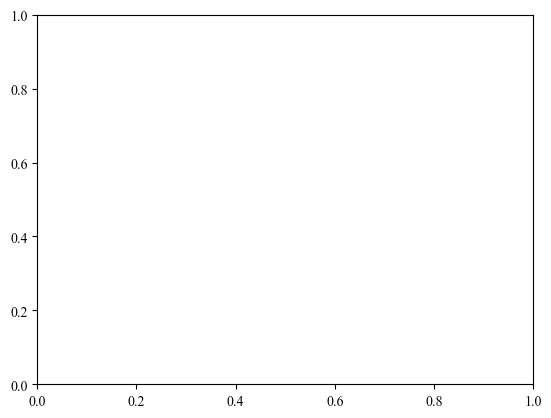

In [6]:
# -*- coding:utf-8 -*-
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
matplotlib.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
 
# 构建数据
x = np.arange(1, max_iter+1)
y = np.random.rand(len(x))
z = F
# u = [37, 31, 19, 57, 29, 86, 36, 37, 45, 64, 42, 57, 50, 24]
 
 
# 绘柱状图
plt.bar(x=x, height=z, label='实际', color='Coral', alpha=0.8)
# plt.bar(x=x, height=u, label='总数', color='LemonChiffon', alpha=0.8)
# 在左侧显示图例
plt.legend(loc="upper left")
 
# 设置标题
plt.title("Detection results")
# 为两条坐标轴设置名称
plt.xlabel("Component number")
plt.ylabel("Number of seam")
 
 
# 画折线图
ax2 = plt.twinx()
ax2.set_ylabel("recall")
# 设置坐标轴范围
ax2.set_ylim([0.5, 1.05]);
plt.plot(x, y, "r", marker='.', c='r', ms=5, linewidth='1', label="Recall")
# 显示数字
for a, b in zip(x, y):
    plt.text(a, b, b, ha='center', va='bottom', fontsize=8)
# 在右侧显示图例
plt.legend(loc="upper right")
plt.savefig("recall.jpg")
 
plt.show()
 
